# Lesson 5: Paired and Repeated Measurements

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Recognize paired, matched, and repeated-measures designs
2. Analyze paired quantitative outcomes using the distribution of within-pair differences
3. Use Wilcoxon signed-rank and McNemar tests when their data structures match
4. Avoid treating repeated observations as independent


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 5.1 Pairing changes the unit of analysis

The Grunfeld dataset follows the same 11 firms across years. Comparing each firm's investment in 1935 with its own
investment in 1954 creates a genuine paired design. The paired t-test is a one-sample t-test on within-firm log changes.
Its assumptions concern those changes—not the two marginal year distributions.


In [2]:
grunfeld = pd.read_csv(DATA_DIR / "grunfeld_investment.csv")
paired = grunfeld.pivot(index="firm", columns="year", values="investment")[[1935, 1954]].dropna()
before_raw = paired[1935].to_numpy()
after_raw = paired[1954].to_numpy()
before = np.log1p(before_raw)
after = np.log1p(after_raw)
change = after-before

paired_test = stats.ttest_rel(after, before)
n = len(change)
mean_change = change.mean()
se = change.std(ddof=1)/np.sqrt(n)
ci = stats.t.interval(.95, n-1, loc=mean_change, scale=se)
dz = mean_change/change.std(ddof=1)
pd.Series({"firms": n, "mean log-investment change": mean_change,
           "CI low": ci[0], "CI high": ci[1], "t": paired_test.statistic,
           "df": n-1, "p": paired_test.pvalue, "Cohen dz": dz})


firms                         1.1000e+01
mean log-investment change    1.1528e+00
CI low                        8.1223e-01
CI high                       1.4934e+00
t                             7.5422e+00
df                            1.0000e+01
p                             1.9655e-05
Cohen dz                      2.2741e+00
dtype: float64

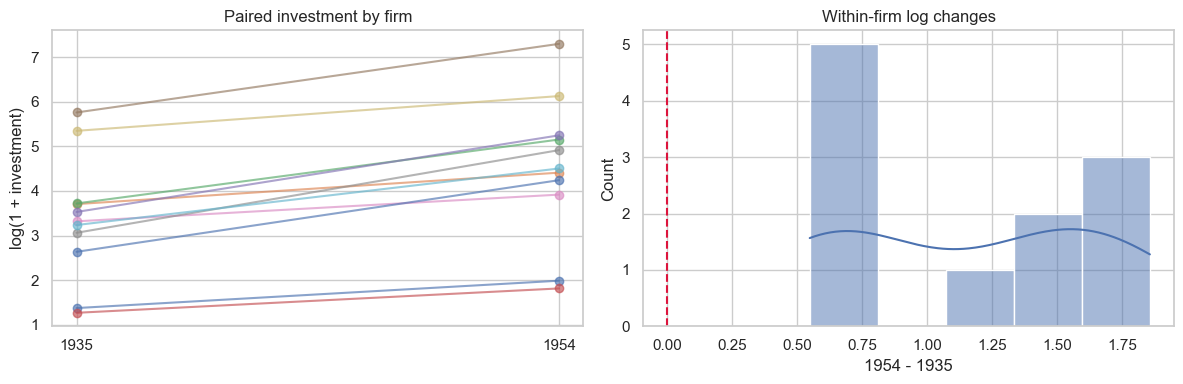

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for firm, row in paired.iterrows():
    axes[0].plot([1935, 1954], np.log1p(row.values), marker="o", alpha=.65)
axes[0].set(xticks=[1935, 1954], ylabel="log(1 + investment)",
            title="Paired investment by firm")
sns.histplot(change, kde=True, ax=axes[1])
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set(title="Within-firm log changes", xlabel="1954 - 1935")
plt.tight_layout(); plt.show()


## 5.2 Rank-based and binary paired tests

- **Wilcoxon signed-rank:** paired quantitative/ordinal data; tests symmetry-centered change and assumes
  a roughly symmetric difference distribution.
- **Sign test:** weaker but needs fewer shape assumptions.
- **McNemar:** paired binary outcomes; uses only discordant pairs.


In [4]:
wilcoxon = stats.wilcoxon(after, before, alternative="two-sided")
from statsmodels.stats.contingency_tables import mcnemar

# A simple paired binary teaching outcome: investment at least 25 (1947 dollars).
threshold = 25
high_1935 = before_raw >= threshold
high_1954 = after_raw >= threshold
paired_binary = pd.crosstab(high_1935, high_1954).reindex(
    index=[False, True], columns=[False, True], fill_value=0).to_numpy()
mc = mcnemar(paired_binary, exact=True)
b, c = paired_binary[0, 1], paired_binary[1, 0]
discordant_or = b/c if c else np.inf
display(pd.DataFrame(paired_binary, index=["1935 below", "1935 at/above"],
                     columns=["1954 below", "1954 at/above"]))
pd.DataFrame({"test": ["Wilcoxon signed-rank", "Exact McNemar"],
              "statistic": [wilcoxon.statistic, mc.statistic],
              "p": [wilcoxon.pvalue, mc.pvalue],
              "effect/note": ["paired log-investment shift", f"discordant OR={discordant_or}"]})


,1954 below,1954 at/above
1935 below,2,3
1935 at/above,0,6


,test,statistic,p,effect/note
0,Wilcoxon signed-rank,0.0,0.001,paired log-investment shift
1,Exact McNemar,0.0,0.250,discordant OR=inf


## Worked example and interpretation

### Preserve the pairing

The Grunfeld example keeps firms observed in both 1935 and 1954, leaving 11 independent **firm pairs**, not 22 independent rows. It applies log(1 + investment) to each year and analyzes each firm's later-minus-earlier change. The mean paired log change is 1.153 with a 95% interval from 0.812 to 1.493; the paired t statistic is 7.54 on 10 degrees of freedom, with p about 0.00002. The connected-firm plot shows the matched trajectories, and the change histogram shows what the paired test summarizes. A Wilcoxon signed-rank test of those paired changes also gives evidence of a shift (p = 0.001), with different rank-based assumptions.

### Why the binary result differs

The same investments are then reduced to whether each firm meets a threshold of 25. Three firms move from below to at/above the threshold and none move the other way. Exact McNemar uses only these **three discordant pairs** and gives p = 0.25. The displayed discordant odds ratio is infinite solely because one cell is zero; it is not a precise effect estimate. The continuous and thresholded analyses answer different questions, and historical changes between years cannot be attributed to a treatment from this before-and-after design.

## Practice and solution

**Practice.** A dataset has three measurements per participant. Why not run three independent t-tests?

<details><summary>Solution</summary>

Measurements within a person are correlated, violating independence, and three tests inflate the
family-wise error rate. Use repeated-measures ANOVA, Friedman, or a mixed model, followed by adjusted
planned contrasts when needed.
</details>

## Key takeaways

- Pairing must be represented in both plots and tests.
- Diagnose the within-pair differences for a paired t-test.
- McNemar is for paired binary outcomes, not independent contingency tables.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
